In [1]:
import pandas as pd
import nltk 
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk import RegexpParser
from nltk.tokenize import sent_tokenize
from nltk.stem import PorterStemmer
from nltk import Tree
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from transformers import TFBertModel, AutoTokenizer
from transformers import logging
from scipy.spatial.distance import cosine
from concurrent.futures import ProcessPoolExecutor
import warnings
import time
from concurrent.futures import ThreadPoolExecutor
import math
# import openai
from transformers import logging
import torch
from sentence_transformers import SentenceTransformer
# import pyphen
from collections import Counter
from collections import defaultdict
from joblib import Parallel, delayed
from scipy.optimize import curve_fit
import itertools
from scipy.special import comb
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import SpectralClustering
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score, silhouette_samples
from gensim.models import CoherenceModel
from gensim.models.ldamodel import LdaModel
from gensim.utils import simple_preprocess

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from itertools import combinations
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')
logging.set_verbosity_error()  # disable warnings from transformer, hugging face package.

In [2]:
## get all the stories.  nine stories in total.
story_all = [] 

data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/boyscout.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v1-pool.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v2-lake.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v1-rookie.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v2-catlady.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/panic.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v1-park.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v2-church.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/stein.pkl")
story_all.append(data)

cleaned_all = []
for index in np.arange(len(story_all)):
    cleaned_data = {key: [str(value) for value in val] for key, val in story_all[index].items()}
    cleaned_all.append(cleaned_data)

## get narrative and recalls from the data.
def fetch_text(input_dic):
    story = "".join(input_dic['narrative'])
    recall = input_dic['recalls']
    return story, recall

story_all, recall_all = zip(*[fetch_text(data) for data in cleaned_all])


In [3]:
## three more stories added to the analysis.
story_additional = [] 
recall_additional = []

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-segments.csv", encoding='utf-8')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-recalls_segmented.csv", encoding='utf-8')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/do-something-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/dosomething-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

additional_story_processed = []
additional_recall_processed = [[] for _ in np.arange(3)]
score_processed_additional = []

for i in np.arange(3):
    # the original story in segment.
    story = story_additional[i]['segment_text']
    story_as_list = story.tolist()
    additional_story_processed.append(story_as_list)

    # get the recall text by each participant.
    recall = recall_additional[i]
    recall_id = recall['recall_id']
    recall_id_set = list(set(recall_id))
    for j in recall_id_set:
        recall_participant = recall[recall['recall_id'] == j]
        recall_content = recall_participant['clause_text']
        recall_as_list = recall_content.tolist()
        additional_recall_processed[i].append(recall_as_list)

In [4]:
additional_story_processed = [' '.join(sublist) for sublist in additional_story_processed]
additional_recall_processed = [[' '.join(additional_recall_processed[story][participant]) for participant in np.arange(len(additional_recall_processed[story]))]
                                for story in np.arange(len(additional_recall_processed))]

## add the new data to the dataset.
story_all = story_all + tuple(additional_story_processed)
recall_all = recall_all + tuple(additional_recall_processed)


In [5]:
model = SentenceTransformer('all-MiniLM-L6-v2')

## 1. divide the data by "." on the sentence level.

In [6]:
story_all_sentence = [story.split(".") for story in story_all]
story_all_sentence = [[sentence + "." for sentence in story if len(sentence) > 3] for story in story_all_sentence]  
    # clean empty strings, and add . back to each sentence.

print(story_all_sentence[0])

['Yeah, I was in the boy scouts at the time.', ' And we was doing the 50-yard dash, racing, but we was at the pier, marked off and so we was doing the 50-yard dash.', ' There was about 8 or 9 of us, you know, going down, coming back.', ' And going down the third time, I caught cramps and I started yelling "Help!", but the fellows didn\'t believe me, you know.', ' They thought I was just trying to catch up, because I was going on or slowing down.', ' So all of them kept going.', ' They leave me.', ' And so I started going down.', ' Scoutmaster was up there.', ' He was watching me.', " But he didn't pay me no attention either.", ' And for no reason at all there was another guy, who had just walked up that minute.', ' He just jumped over and grabbed me.']


In [7]:
recall_all_sentence = [[recall.split(".") for recall in participant] for participant in recall_all]
recall_all_sentence = [[[sentence + "." for sentence in recall if len(sentence) > 3] for recall in participant] for participant in recall_all_sentence]

print(recall_all_sentence[0][0])

['Yeh, so I was in the boy scouts and we was doing the 50 yard dash.', ' We was doing the 50 yard dash and two or three times in and I got the cramps.', ' I started yelling for help but nobody believed me because they thought I was trying to catch up because I was slowing down.', ' The scoutmaster was there and he paid me no attention.', ' Then suddenly a man came up at that time and he grabbed me.']


In [8]:
story_emb_sentence_all = [model.encode(story) for story in story_all_sentence]

recall_emb_sentence_all = [[model.encode(participant) for participant in story if len(participant)>2]  # remove empty recalls.
                    for story in recall_all_sentence]

##### Clustering on sentences.

## 2. divide the narrative into units of words.

In [9]:
import re
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()

def preprocess(text):
    """Tokenize, lowercase, remove non-word tokens and stopwords, then stem."""
    words = [
        stemmer.stem(word.lower())
        for sentence in sent_tokenize(text)
        for word in word_tokenize(sentence)
        if re.match(r'^\w+$', word) and word.lower() not in stop_words
    ]
    return words

def preprocess_sentences(text):
    """tokenizes text into words. lowercase."""
    return [
        [word.lower() for word in word_tokenize(sentence)
         if re.match(r'^\w+$', word)]
        for sentence in sent_tokenize(text)
    ]

story_words_all_root  = [preprocess(story) for story in story_all]

recall_words_all_root = [
    [preprocess(recall) for recall in story_recalls]
    for story_recalls in recall_all
]

print(story_words_all_root[0][:20])
print(f"Narrative 1, participant 1 recall words: {recall_words_all_root[0][0][:20]}")


['yeah', 'boy', 'scout', 'time', 'dash', 'race', 'pier', 'mark', 'dash', '8', '9', 'us', 'know', 'go', 'come', 'back', 'go', 'third', 'time', 'caught']
Narrative 1, participant 1 recall words: ['yeh', 'boy', 'scout', '50', 'yard', 'dash', '50', 'yard', 'dash', 'two', 'three', 'time', 'got', 'cramp', 'start', 'yell', 'help', 'nobodi', 'believ', 'thought']


In [10]:
# group them by cosine distance.

from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

threshold = np.cos(np.radians(60))  # cos(60°) = 0.5

story_word_groups = [[] for _ in range(12)]

for i in range(12):
    words = story_words_all_root[i]
    if len(words) == 0:
        continue

    # embed unique stemmed words
    unique_words = list(set(words))
    embeddings = model.encode(unique_words)

    # pairwise cosine similarity
    sim_matrix = cosine_similarity(embeddings)

    # build graph: connect words with similarity >= threshold
    G = nx.Graph()
    G.add_nodes_from(range(len(unique_words)))
    for a in range(len(unique_words)):
        for b in range(a+1, len(unique_words)):
            if sim_matrix[a, b] >= threshold:
                G.add_edge(a, b)

    # connected components = groups
    groups = [[unique_words[idx] for idx in component]
              for component in nx.connected_components(G)]
    story_word_groups[i] = groups

    print(f"Narrative {i+1}: {len(groups)} groups from {len(unique_words)} unique words")

Narrative 1: 35 groups from 41 unique words
Narrative 2: 47 groups from 54 unique words
Narrative 3: 43 groups from 53 unique words
Narrative 4: 68 groups from 89 unique words
Narrative 5: 66 groups from 95 unique words
Narrative 6: 73 groups from 124 unique words
Narrative 7: 71 groups from 139 unique words
Narrative 8: 100 groups from 196 unique words
Narrative 9: 109 groups from 235 unique words
Narrative 10: 108 groups from 207 unique words
Narrative 11: 99 groups from 295 unique words
Narrative 12: 95 groups from 149 unique words


In [11]:
## calculate recall rate of the words.

print(story_word_groups[3])


[['transfer'], ['forc'], ['braveri'], ['book'], ['left'], ['never'], ['messag'], ['whatev'], ['young', 'year', 'daughter', 'girl', 'old'], ['littl'], ['think', 'seem', 'look'], ['locat'], ['return', 'back', 'apart', 'went', 'away', 'go'], ['trace'], ['said', 'talk', 'say'], ['day'], ['near'], ['park'], ['rooki'], ['frank'], ['open', 'offer', 'accept'], ['resolv'], ['polic'], ['charm'], ['could'], ['scarf'], ['tri'], ['sit', 'chair'], ['fit', 'big'], ['leav'], ['mitchel'], ['alway'], ['calm'], ['even'], ['search'], ['found'], ['deputi'], ['chief'], ['arriv'], ['mouth', 'face'], ['anyth'], ['station'], ['man'], ['better', 'good', 'well'], ['enthusiast'], ['strateg'], ['nevertheless'], ['hand'], ['manag'], ['end'], ['issu'], ['award'], ['crimin', 'intimid'], ['truth'], ['observ'], ['caught'], ['forget'], ['scold'], ['veteran'], ['impress'], ['notori'], ['chatterbox'], ['propos'], ['get'], ['one'], ['fond'], ['run'], ['ca']]


In [12]:
threshold = np.cos(np.radians(60))

freq_all = []
recall_rate_all = []

for i in range(12):
    story_words = story_words_all_root[i]
    if not story_words:
        continue

    unique_words = list(set(story_words))
    word_freq = {w: story_words.count(w) for w in unique_words}

    # embed unique story words
    story_emb = model.encode(unique_words)

    # recall rate for each unique word
    participant_rates = []
    for participant_words in recall_words_all_root[i]:
        if not participant_words:
            continue
        recall_emb = model.encode(participant_words)
        sim_matrix = cosine_similarity(story_emb, recall_emb)
        recalled = (np.max(sim_matrix, axis=1) >= threshold).astype(float)
        participant_rates.append(recalled)

    if not participant_rates:
        continue

    avg_recall = np.mean(participant_rates, axis=0)

    for j, word in enumerate(unique_words):
        freq_all.append(word_freq[word])
        recall_rate_all.append(avg_recall[j])

### Results.

In [13]:
from collections import defaultdict

word_freq_dict_all = []

for i in range(12):
    story_words = story_words_all_root[i]
    if not story_words:
        word_freq_dict_all.append({})
        continue
    word_freq_dict_all.append({w: story_words.count(w) for w in set(story_words)})

for key, val in list(word_freq_dict_all[8].items())[:20]:
    print(f"{key!r}: {val}")

freq_to_words = defaultdict(list)
for d in word_freq_dict_all:
    for word, freq in d.items():
        freq_to_words[freq].append(word)

print(f"{'Freq':>5}  {'Examples'}")
print("-" * 40)
for freq in sorted(freq_to_words.keys()):
    words    = freq_to_words[freq]
    examples = ", ".join(words[:3])
    print(f"{freq:>5}  {examples}")


'whoever': 1
'glass': 1
'street': 3
'food': 1
'hurt': 1
'final': 1
'cow': 1
'much': 2
'thought': 1
'came': 4
'sooner': 1
'sick': 1
'hour': 1
'left': 3
'provid': 1
'person': 1
'happen': 5
'assert': 1
'put': 3
'never': 1
 Freq  Examples
----------------------------------------
    1  cramp, scout, thought
    2  know, dash, start
    3  go, manner, chest
    4  day, bit, manag
    5  go, start, uh
    6  could, feel, father
    7  hous, told, clang
    8  grandpa, polic, see
    9  hospit, guy
   10  went, move, came
   11  go, went, call
   12  get
   13  know, daughter
   14  mother, hunt
   15  got
   16  uh, well, said
   17  know
   19  say, mari
   41  said


In [14]:
# ── bin by frequency and average ─────────────────────────────────────────────
freq_all = np.array(freq_all)
recall_rate_all = np.array(recall_rate_all)

max_freq = int(np.percentile(freq_all,99.9999))  # ignore extreme outliers
bins = np.arange(1, max_freq + 2)
bin_means, bin_stds, bin_counts = [], [], []

for f in range(1, max_freq + 1):
    vals = recall_rate_all[freq_all == f]
    if len(vals) > 0:
        bin_means.append(np.mean(vals))
        bin_stds.append(np.std(vals))
        bin_counts.append(f)

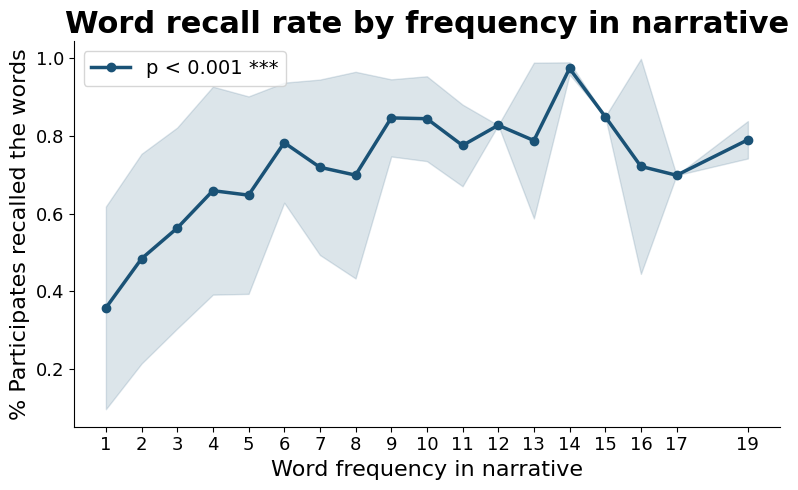

In [15]:
# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(bin_counts, bin_means, '-o', color='#1a5276', lw=2.5, markersize=6, label=f"p < 0.001 ***")
ax.fill_between(bin_counts,
                np.array(bin_means) - np.array(bin_stds),
                np.array(bin_means) + np.array(bin_stds),
                color='#1a5276', alpha=0.15)

ax.set_xlabel("Word frequency in narrative", fontsize=16)
ax.set_ylabel("% Participates recalled the words", fontsize=16)
ax.set_title("Word recall rate by frequency in narrative", fontsize=22, fontweight='bold')
ax.tick_params(labelsize=13)
ax.spines[['top', 'right']].set_visible(False)

ax.set_xticks(bin_counts)
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

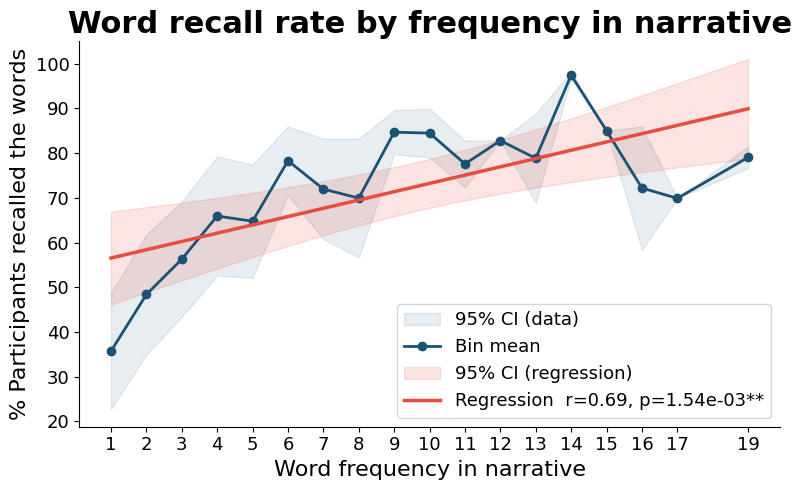

In [16]:
from scipy.stats import t as sp_t, linregress
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

x = np.array(bin_counts, dtype=float)
y = np.array(bin_means,  dtype=float)

# ── regression ──
sl, ic, r_p, p_param, _ = linregress(x, y)
n      = len(x)
y_hat  = sl * x + ic
s_e    = np.sqrt(np.sum((y - y_hat)**2) / (n - 2))
x_mean = np.mean(x)
Sxx    = np.sum((x - x_mean)**2)
t_crit = sp_t.ppf(0.975, df=n - 2)

x_fine   = np.linspace(x.min(), x.max(), 300)
y_fine   = sl * x_fine + ic
ci_width = t_crit * s_e * np.sqrt(1/n + (x_fine - x_mean)**2 / Sxx)
ci_lower = y_fine - ci_width
ci_upper = y_fine + ci_width

# ── raw CI (±SEM across stories) ──
n_stories = len(bin_stds)
bin_sems  = np.array(bin_stds) / np.sqrt(n_stories)
t_crit_ci = sp_t.ppf(0.975, df=n_stories - 1)
raw_lower = y - t_crit_ci * bin_sems
raw_upper = y + t_crit_ci * bin_sems

# ── plot ──
fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(x, raw_lower, raw_upper, color='#1a5276', alpha=0.10, label="95% CI (data)")
ax.plot(x, y, '-o', color='#1a5276', lw=2, markersize=6, label="Bin mean")

ax.fill_between(x_fine, ci_lower, ci_upper, color='#e74c3c', alpha=0.15, label="95% CI (regression)")
ax.plot(x_fine, y_fine, '-', color='#e74c3c', lw=2.5,
        label=f"Regression  r={r_p:.2f}, p={p_param:.2e}**")

ax.set_xlabel("Word frequency in narrative", fontsize=16)
ax.set_ylabel("% Participants recalled the words", fontsize=16)
ax.set_title("Word recall rate by frequency in narrative", fontsize=22, fontweight='bold')
ax.tick_params(labelsize=13)
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, _: f"{val*100:.0f}"))
ax.spines[['top', 'right']].set_visible(False)

ax.set_xticks(bin_counts)
ax.legend(fontsize=13)
plt.tight_layout()
plt.show()


In [17]:
from scipy.stats import linregress, t as sp_t, norm as sp_norm
import statsmodels.api as sm
import numpy as np

x = np.array(bin_counts, dtype=float)
y = np.array(bin_means,  dtype=float)
mask = ~(np.isnan(x) | np.isnan(y))
x, y = x[mask], y[mask]
nc   = len(x)
dfc  = nc - 2

n_perm = 10000
n_boot = 10000

# ═══════════════════════════════════════════════════════
# 1. PARAMETRIC REGRESSION
# ═══════════════════════════════════════════════════════
sl, ic, r_p, p_param, se = linregress(x, y)
r2       = r_p**2
cohen_f2 = r2 / (1 - r2 + 1e-10)
t_obs    = r_p * np.sqrt(dfc) / np.sqrt(1 - r_p**2 + 1e-10)
t_crit   = sp_t.ppf(0.975, dfc)
power    = (1 - sp_t.cdf(t_crit, dfc, loc=abs(t_obs))
              + sp_t.cdf(-t_crit, dfc, loc=abs(t_obs)))

z_r  = np.arctanh(np.clip(r_p, -0.9999, 0.9999))
se_z = 1 / np.sqrt(nc - 3)
ci_r = [np.tanh(z_r - 1.96*se_z), np.tanh(z_r + 1.96*se_z)]

X_sm     = sm.add_constant(x)
m_sm     = sm.OLS(y, X_sm).fit()
ci_slope = m_sm.conf_int(alpha=0.05)[1]

print("=" * 60)
print("  PARAMETRIC REGRESSION")
print("=" * 60)
print(f"  n              = {nc}")
print(f"  slope          = {sl:.4f}  CI=[{ci_slope[0]:.4f}, {ci_slope[1]:.4f}]")
print(f"  intercept      = {ic:.4f}")
print(f"  t({dfc})        = {t_obs:.4f}")
print(f"  p              = {p_param:.4e}")
print(f"  Pearson r      = {r_p:.4f}  CI=[{ci_r[0]:.4f}, {ci_r[1]:.4f}]")
print(f"  R²             = {r2:.4f}  ({r2*100:.1f}%)")
print(f"  Cohen's f²     = {cohen_f2:.4f}  ({'small' if cohen_f2<0.15 else 'medium' if cohen_f2<0.35 else 'large'})")
print(f"  Power          = {power:.4f}")

# ═══════════════════════════════════════════════════════
# 2. PERMUTATION
# ═══════════════════════════════════════════════════════
rng_p  = np.random.default_rng(0)
r_null = np.array([linregress(rng_p.permutation(x), y)[2] for _ in range(n_perm)])
p_perm = np.mean(np.abs(r_null) >= np.abs(r_p))

print(f"\n{'='*60}")
print(f"  PERMUTATION  (n={n_perm})")
print(f"{'='*60}")
print(f"  r_obs          = {r_p:.4f}")
print(f"  p_perm         = {p_perm:.4f}")
print(f"  null r: mean={r_null.mean():.4f}, std={r_null.std():.4f}, "
      f"95th={np.percentile(np.abs(r_null), 95):.4f}")

# ═══════════════════════════════════════════════════════
# 3. BOOTSTRAP
# ═══════════════════════════════════════════════════════
rng_b = np.random.default_rng(1)
r_b, sl_b, r2_b, t_b, f2_b = [], [], [], [], []

for _ in range(n_boot):
    idx = rng_b.choice(nc, nc, replace=True)
    xb, yb = x[idx], y[idx]
    if len(np.unique(xb)) < 2:
        continue
    sl_, _, r_, _, _ = linregress(xb, yb)
    r2_  = r_**2
    t_   = r_ * np.sqrt(nc - 2) / np.sqrt(1 - r_**2 + 1e-10)
    r_b.append(r_);   sl_b.append(sl_)
    r2_b.append(r2_); t_b.append(t_)
    f2_b.append(r2_ / (1 - r2_ + 1e-10))

r_b  = np.array(r_b);  sl_b = np.array(sl_b)
r2_b = np.array(r2_b); t_b  = np.array(t_b)
f2_b = np.array(f2_b)

p_boot   = 2 * min(np.mean(r_b <= 0), np.mean(r_b >= 0))
pow_boot = np.mean(np.abs(t_b) >= t_crit)

print(f"\n{'='*60}")
print(f"  BOOTSTRAP  (n={n_boot})")
print(f"{'='*60}")
print(f"  p              = {p_boot:.4f}")
print(f"  slope          = {np.mean(sl_b):.4f}  CI=[{np.percentile(sl_b,2.5):.4f}, {np.percentile(sl_b,97.5):.4f}]")
print(f"  r              = {np.mean(r_b):.4f}  CI=[{np.percentile(r_b,2.5):.4f}, {np.percentile(r_b,97.5):.4f}]")
print(f"  R²             = {np.mean(r2_b):.4f}  CI=[{np.percentile(r2_b,2.5):.4f}, {np.percentile(r2_b,97.5):.4f}]")
print(f"  Cohen's f²     = {np.mean(f2_b):.4f}  CI=[{np.percentile(f2_b,2.5):.4f}, {np.percentile(f2_b,97.5):.4f}]")
print(f"  Power          = {pow_boot:.4f}")
print("=" * 60)


  PARAMETRIC REGRESSION
  n              = 18
  slope          = 0.0185  CI=[0.0082, 0.0289]
  intercept      = 0.5468
  t(16)        = 3.8111
  p              = 1.5363e-03
  Pearson r      = 0.6898  CI=[0.3288, 0.8749]
  R²             = 0.4758  (47.6%)
  Cohen's f²     = 0.9078  (large)
  Power          = 0.9449

  PERMUTATION  (n=10000)
  r_obs          = 0.6898
  p_perm         = 0.0014
  null r: mean=-0.0024, std=0.2460, 95th=0.4691

  BOOTSTRAP  (n=10000)
  p              = 0.0032
  slope          = 0.0186  CI=[0.0064, 0.0318]
  r              = 0.6801  CI=[0.3501, 0.8813]
  R²             = 0.4805  CI=[0.1226, 0.7767]
  Cohen's f²     = 1.1686  CI=[0.1398, 3.4778]
  Power          = 0.9344


### Sensitivity test.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import t as sp_t, linregress

angles     = [55, 60, 65]
colors     = ['#2471a3', '#e74c3c', '#27ae60']
alpha_fill = 0.12

results_reg = {}

for angle in angles:
    thr = np.cos(np.radians(angle))

    freq_all, recall_rate_all = [], []

    for i in range(12):
        story_words = story_words_all_root[i]
        if not story_words:
            continue

        unique_words = list(set(story_words))
        word_freq    = {w: story_words.count(w) for w in unique_words}
        story_emb    = model.encode(unique_words)

        participant_rates = []
        for participant_words in recall_words_all_root[i]:
            if not participant_words:
                continue
            recall_emb = model.encode(participant_words)
            sim        = cosine_similarity(story_emb, recall_emb)
            recalled   = (np.max(sim, axis=1) >= thr).astype(float)
            participant_rates.append(recalled)

        if not participant_rates:
            continue

        avg_recall = np.mean(participant_rates, axis=0)
        for j, word in enumerate(unique_words):
            freq_all.append(word_freq[word])
            recall_rate_all.append(avg_recall[j])

    freq_all        = np.array(freq_all)
    recall_rate_all = np.array(recall_rate_all)

    max_freq   = int(np.percentile(freq_all, 99.9999))
    bin_means, bin_stds, bin_counts = [], [], []
    for f in range(1, max_freq + 1):
        vals = recall_rate_all[freq_all == f]
        if len(vals) > 0:
            bin_means.append(np.mean(vals))
            bin_stds.append(np.std(vals))
            bin_counts.append(f)

    x = np.array(bin_counts, dtype=float)
    y = np.array(bin_means,  dtype=float)

    sl, ic, r_p, p_param, se_sl = linregress(x, y)
    n      = len(x)
    y_hat  = sl * x + ic
    s_e    = np.sqrt(np.sum((y - y_hat)**2) / (n - 2))
    x_mean = np.mean(x)
    Sxx    = np.sum((x - x_mean)**2)
    t_crit = sp_t.ppf(0.975, df=n - 2)

    x_fine   = np.linspace(x.min(), x.max(), 300)
    y_fine   = sl * x_fine + ic
    ci_width = t_crit * s_e * np.sqrt(1/n + (x_fine - x_mean)**2 / Sxx)

    results_reg[angle] = dict(
        x=x, y=y, sl=sl, ic=ic, r=r_p, p=p_param, n=n,
        x_fine=x_fine, y_fine=y_fine,
        ci_lower=y_fine - ci_width, ci_upper=y_fine + ci_width,
    )
    print(f"Angle {angle}°: n_bins={n}, slope={sl:.4f}, r={r_p:.3f}, p={p_param:.3e}")



Angle 55°: n_bins=18, slope=0.0229, r=0.710, p=9.713e-04


In [ ]:
# ── figure: overlaid regression lines + CI bands ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))

for angle, col in zip(angles, colors):
    r = results_reg[angle]
    sig = ('***' if r['p'] < 0.001 else '**' if r['p'] < 0.01
           else '*' if r['p'] < 0.05 else 'ns')
    ax.fill_between(r['x_fine'], r['ci_lower'], r['ci_upper'],
                    color=col, alpha=alpha_fill)
    ax.plot(r['x_fine'], r['y_fine'], '-', color=col, lw=2.5,
            label=f"{angle}°  r={r['r']:.2f}, p={r['p']:.2e} {sig}")
    ax.plot(r['x'], r['y'], 'o', color=col, markersize=5, alpha=0.55)

ax.set_xlabel("Word frequency in narrative", fontsize=15)
ax.set_ylabel("% Participants recalled the word", fontsize=15)
ax.set_title("Sensitivity analysis: word recall × frequency regression",
             fontsize=18, fontweight='bold')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*100:.0f}"))
ax.tick_params(labelsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=12, title="Similarity threshold", title_fontsize=11)
plt.tight_layout()
plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("  Sensitivity — word-frequency recall regression")
print(f"{'='*65}")
print(f"  {'Angle':>6}  {'n_bins':>6}  {'slope':>8}  {'r':>6}  {'p':>10}  sig")
print(f"  {'-'*60}")
for angle in angles:
    r   = results_reg[angle]
    sig = ('***' if r['p'] < 0.001 else '**' if r['p'] < 0.01
           else '*' if r['p'] < 0.05 else 'ns')
    print(f"  {angle:>5}°  {r['n']:>6}  {r['sl']:>8.5f}  "
          f"{r['r']:>6.3f}  {r['p']:>10.4e}  {sig}")
print(f"{'='*65}")
